# Weblate data vizualisation
Romain Darous. <br> <br>

After collecting Weblate translation files, stored language per language in the folder ``/os_by_language``, it is interesting to take a look at the distribution of the available data per language.

### Importing required modules

In [1]:
import matplotlib.pyplot as plt
import os
import pandas as pd
from collections import defaultdict
import numpy as np

### Storing data analytics
- ``file_nb`` : number of .csv files per language,
- ``string_nb`` : number of translated strings per language,
- ``word_nb`` : number of translated words per language (with duplicates).

In [6]:
languages = os.listdir("./os_by_language/dataset")
stats = defaultdict( lambda : defaultdict(int))

for language in languages :
    path = f'./os_by_language/dataset/{language}'
    files = os.listdir(path)
    if len(files) == 0 :
        os.rmdir(path)
        continue
    stats[language]["file_nb"] = len(files)
    for file in files :
        df = pd.read_csv(f'{path}/{file}')
        stats[language]["string_nb"] += df.shape[0]
        try :
            for string in df["target"] :
                if not pd.isnull(string):
                    stats[language]["word_nb"] += len(string.split(' '))
        except :
            print(df, file)

   source  target                      last-update
0       5       5  2024-04-11 16:06:00.000000+0000 ubuntu-noble-LC_MESSAGES-sssd-docs-be.csv


### Displaying data analytics

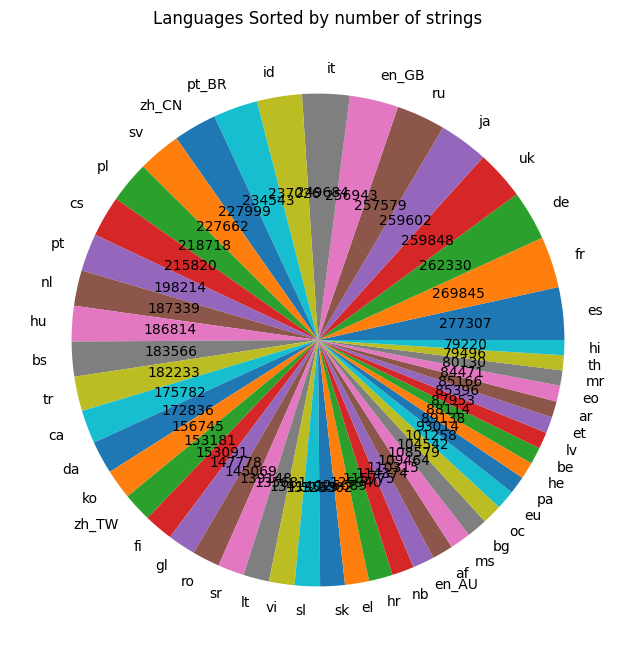

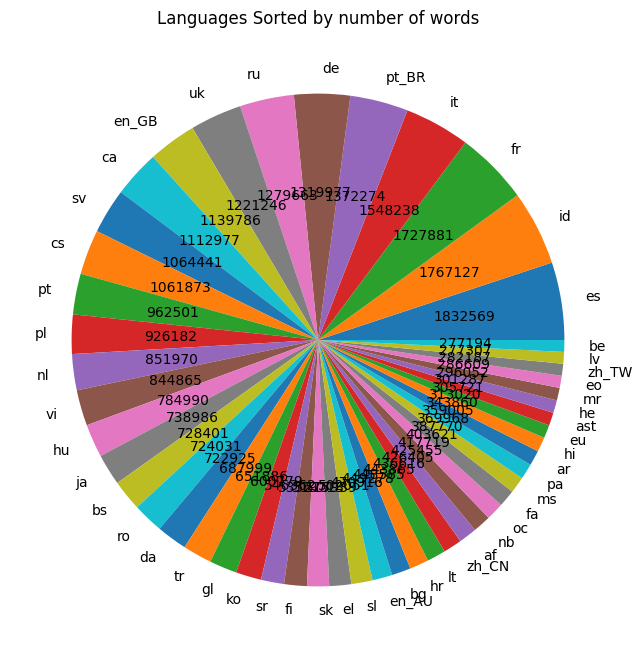

{277307: 'es', 269845: 'fr', 262330: 'de', 259848: 'uk', 259602: 'ja', 257579: 'ru', 256943: 'en_GB', 249684: 'it', 237026: 'id', 234543: 'pt_BR', 227999: 'zh_CN', 227662: 'sv', 218718: 'pl', 215820: 'cs', 198214: 'pt', 187339: 'nl', 186814: 'hu', 183566: 'bs', 182233: 'tr', 175782: 'ca', 172836: 'da', 156745: 'ko', 153181: 'zh_TW', 153091: 'fi', 147778: 'gl', 145069: 'ro', 139148: 'sr', 135681: 'lt', 134140: 'vi', 133559: 'sl', 129502: 'sk', 126689: 'el', 125940: 'hr', 115775: 'nb', 114374: 'en_AU', 110315: 'af', 109464: 'ms', 108579: 'bg', 104542: 'oc', 101258: 'eu', 93014: 'pa', 89138: 'he', 88114: 'be', 87953: 'lv', 85396: 'et', 85166: 'ar', 84471: 'eo', 80130: 'mr', 79496: 'th', 79220: 'hi'}


In [13]:
max_display = 50

# Sort languages by number of strings
sorted_languages_by_strings = sorted(stats.keys(), key=lambda x: stats[x]['string_nb'], reverse=True)
num_strings = [stats[language]['string_nb'] for language in sorted_languages_by_strings]

plt.figure(figsize=(14, 8))  # Increase the figure size
plt.pie(num_strings[:max_display], labels=sorted_languages_by_strings[:max_display], 
        autopct=lambda pct: f"{pct * sum(num_strings[:max_display]) / 100:.0f}")
plt.title('Languages Sorted by number of strings')
plt.show()

# Sort languages by number of words
sorted_languages_by_words = sorted(stats.keys(), key=lambda x: stats[x]['word_nb'], reverse=True)
num_words = [stats[language]['word_nb'] for language in sorted_languages_by_words]

plt.figure(figsize=(14, 8))  # Increase the figure size
plt.pie(num_words[:max_display], labels=sorted_languages_by_words[:max_display], 
        autopct=lambda pct: f"{pct * sum(num_words[:max_display]) / 100:.0f}")
plt.title('Languages Sorted by number of words')
plt.show()

print({num_strings[:max_display][i]: sorted_languages_by_strings[:max_display][i] for i in range(max_display)})


In [14]:
# Filter languages with more than 50,000 strings
languages_above_50k_strings = [language for language in sorted_languages_by_strings if stats[language]['string_nb'] > 50000]

print(languages_above_50k_strings)

['es', 'fr', 'de', 'uk', 'ja', 'ru', 'en_GB', 'it', 'id', 'pt_BR', 'zh_CN', 'sv', 'pl', 'cs', 'pt', 'nl', 'hu', 'bs', 'tr', 'ca', 'da', 'ko', 'zh_TW', 'fi', 'gl', 'ro', 'sr', 'lt', 'vi', 'sl', 'sk', 'el', 'hr', 'nb', 'en_AU', 'af', 'ms', 'bg', 'oc', 'eu', 'pa', 'he', 'be', 'lv', 'et', 'ar', 'eo', 'mr', 'th', 'hi', 'ast', 'sr@latin', 'fa', 'km', 'ka', 'nn', 'ta', 'ca@valencia', 'gu', 'zh_HK', 'my', 'is', 'bn', 'sq', 'ug']


### Statistics on the dataset
First one may take a look at the common statistic values of the dataset :
- Mean and standard deviation of the number of translated words and strings,
- Most and least translated languages for data imbalance evaluation.

In [3]:
# Calculate the mean and standard deviation
mean_strings = np.mean(num_strings)
mean_words = np.mean(num_words)
std_strings = np.std(num_strings)
std_words = np.std(num_words)

mean_std_df = pd.DataFrame({'Mean nb of strings': [np.round(mean_strings)],
                            'Mean nb of words': [np.round(mean_words)],
                            'Standard Deviation of strings': [np.round(std_strings)],
                            'Standard Deviation of words': [np.round(std_words)]})
mean_std_df

NameError: name 'num_strings' is not defined

In [9]:
df = pd.DataFrame({'Language': [sorted_languages_by_words[0], sorted_languages_by_words[-1]],
                       'Number of strings': [num_strings[0], num_strings[-1]],
                       'Number of words': [num_words[0], num_words[-1]]})
df



,Language,Number of strings,Number of words
0,id,126871,1337485
1,gv,2,5
